# FINAL — Transformer Set Deep SVDD per Emerging Jets


Input previsto:

```text
FINAL/processed/repr2_sequences.npz
```

Usa la rappresentazione sequenziale creata dal preprocessing:

```text
X_bkg_train       -> tracce padded QCD train
mask_bkg_train    -> mask tracce valide QCD train
jet_bkg_train     -> feature jet QCD train

X_bkg_eval        -> tracce padded QCD eval
mask_bkg_eval     -> mask tracce valide QCD eval
jet_bkg_eval      -> feature jet QCD eval

X_sig             -> tracce padded signal EJ
mask_sig          -> mask tracce valide signal EJ
jet_sig           -> feature jet signal EJ
```

Schema:

```text
bkg_train -> training Deep SVDD
bkg_eval  -> diviso in validation QCD + test QCD
sig       -> test signal EJ
```

Il modello è unsupervised:

```text
training: solo QCD/background
score: distanza dal centro SVDD nello spazio latente
```

Il Deep SVDD è un metodo di anomaly detection non supervisionato.
L’idea è imparare una rappresentazione latente in cui gli eventi QCD normali siano concentrati vicino a un centro c.

Durante il training il modello vede solo background QCD e viene ottimizzato per portare questi eventi il più vicino possibile al centro SVDD. Dopo il training, lo score di anomalia è dato dalla distanza dal centro:

score = || z - c ||²

dove z è la rappresentazione latente prodotta dal modello.

Se un jet è simile al QCD, dovrebbe finire vicino al centro e avere score basso.
Se invece è più anomalo, ad esempio compatibile con un Emerging Jet, dovrebbe finire più lontano e avere score alto.

## 1. Import, seed e device

In [10]:
from pathlib import Path
import json
import copy
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path e caricamento `repr2_sequences.npz`

In [11]:
# Funziona sia se il notebook è lanciato da FINAL/notebooks, sia se è lanciato dalla root del progetto, ma attenzione ai path

CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr2_sequences.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo repr2_sequences.npz. "
        "Controlla che esista in FINAL/processed/repr2_sequences.npz "
        "oppure modifica PROCESSED_PATH manualmente."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "transformer_deep_svdd"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)
print("\nKeys in repr2_sequences.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr2_sequences.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\transformer_deep_svdd

Keys in repr2_sequences.npz:
  X_bkg_train                         shape=(200000, 200, 16) dtype=float32
  mask_bkg_train                      shape=(200000, 200) dtype=bool
  X_bkg_eval                          shape=(200000, 200, 16) dtype=float32
  mask_bkg_eval                       shape=(200000, 200) dtype=bool
  X_sig                               shape=(61966, 200, 16) dtype=float32
  mask_sig                            shape=(61966, 200) dtype=bool
  jet_bkg_train                       shape=(200000, 15) dtype=float32
  jet_bkg_eval                        shape=(200000, 15) dtype=float32
  jet_sig                             shape=(61966, 15) dtype=float32
  track_feature_names                 shape=(16,) dtype=ob

## 3. Loader robusto delle chiavi

In [12]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None


track_train_key = first_existing_key(
    data,
    ["X_bkg_train", "X_tracks_bkg_train", "tracks_bkg_train", "X_tracks_train", "X_train"],
)

mask_train_key = first_existing_key(
    data,
    ["mask_bkg_train", "track_mask_bkg_train", "track_mask_train", "mask_train"],
)

jet_train_key = first_existing_key(
    data,
    ["jet_bkg_train", "X_jets_bkg_train", "X_jets_train", "jets_bkg_train", "jets_train"],
)

track_eval_key = first_existing_key(
    data,
    ["X_bkg_eval", "X_tracks_bkg_eval", "tracks_bkg_eval", "X_tracks_eval", "X_eval"],
)

mask_eval_key = first_existing_key(
    data,
    ["mask_bkg_eval", "track_mask_bkg_eval", "track_mask_eval", "mask_eval"],
)

jet_eval_key = first_existing_key(
    data,
    ["jet_bkg_eval", "X_jets_bkg_eval", "X_jets_eval", "jets_bkg_eval", "jets_eval"],
)

track_sig_key = first_existing_key(
    data,
    ["X_sig", "X_tracks_sig", "tracks_sig", "X_signal", "X_tracks_signal"],
)

mask_sig_key = first_existing_key(
    data,
    ["mask_sig", "track_mask_sig", "track_mask_signal", "mask_signal"],
)

jet_sig_key = first_existing_key(
    data,
    ["jet_sig", "X_jets_sig", "X_jets_signal", "jets_sig", "jets_signal"],
)

track_feature_key = first_existing_key(
    data,
    ["track_feature_names", "tracks_feature_names"],
    required=False,
)

jet_feature_key = first_existing_key(
    data,
    ["jet_feature_names", "jets_feature_names"],
    required=False,
)

X_tracks_train_raw = np.asarray(data[track_train_key], dtype=np.float32)
mask_train_raw = np.asarray(data[mask_train_key]).astype(bool)
X_jets_train_raw = np.asarray(data[jet_train_key], dtype=np.float32)

X_tracks_eval_raw = np.asarray(data[track_eval_key], dtype=np.float32)
mask_eval_raw = np.asarray(data[mask_eval_key]).astype(bool)
X_jets_eval_raw = np.asarray(data[jet_eval_key], dtype=np.float32)

X_tracks_sig_raw = np.asarray(data[track_sig_key], dtype=np.float32)
mask_sig_raw = np.asarray(data[mask_sig_key]).astype(bool)
X_jets_sig_raw = np.asarray(data[jet_sig_key], dtype=np.float32)

if track_feature_key is not None:
    track_feature_names = [str(x) for x in data[track_feature_key].tolist()]
else:
    track_feature_names = [f"track_f{i}" for i in range(X_tracks_train_raw.shape[-1])]

if jet_feature_key is not None:
    jet_feature_names = [str(x) for x in data[jet_feature_key].tolist()]
else:
    jet_feature_names = [f"jet_f{i}" for i in range(X_jets_train_raw.shape[-1])]

print("Selected keys:")
print("tracks train:", track_train_key, X_tracks_train_raw.shape)
print("mask train:", mask_train_key, mask_train_raw.shape)
print("jets train:", jet_train_key, X_jets_train_raw.shape)
print("tracks eval:", track_eval_key, X_tracks_eval_raw.shape)
print("mask eval:", mask_eval_key, mask_eval_raw.shape)
print("jets eval:", jet_eval_key, X_jets_eval_raw.shape)
print("tracks sig:", track_sig_key, X_tracks_sig_raw.shape)
print("mask sig:", mask_sig_key, mask_sig_raw.shape)
print("jets sig:", jet_sig_key, X_jets_sig_raw.shape)

print("\nJet features:", jet_feature_names)
print("\nTrack features:", track_feature_names)

Selected keys:
tracks train: X_bkg_train (200000, 200, 16)
mask train: mask_bkg_train (200000, 200)
jets train: jet_bkg_train (200000, 15)
tracks eval: X_bkg_eval (200000, 200, 16)
mask eval: mask_bkg_eval (200000, 200)
jets eval: jet_bkg_eval (200000, 15)
tracks sig: X_sig (61966, 200, 16)
mask sig: mask_sig (61966, 200)
jets sig: jet_sig (61966, 15)

Jet features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau4_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']

Track features: ['pt_log1p', 'd0_log1p', 'z0SinTheta', 'deta', 'dphi', 'qOverP', 'chiSquared', 'radiusOfFirstHit', 'IP3D_signed_d0_significance', 'IP3D_signed_z0_significance', 'numberOfPixelHits', 'numberOfInnermostPixelLayerHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']


## 4. Anti-leakage check

In [13]:
FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

bad_features = []

for name in jet_feature_names + track_feature_names:
    for bad in FORBIDDEN_SUBSTRINGS:
        if bad.lower() in name.lower():
            bad_features.append(name)

if bad_features:
    print("ERRORE: trovate feature potenzialmente leaky negli input:")
    for f in bad_features:
        print("  ", f)
    raise RuntimeError("Leakage check failed. Rimuovi queste feature dal preprocessing.")
else:
    print("Leakage check OK: nessuna feature vietata trovata negli input.")

Leakage check OK: nessuna feature vietata trovata negli input.


## 5. Pulizia array e split eval in validation/test QCD

In [14]:
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", np.sum(~finite))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


X_tracks_train_raw = finite_array(X_tracks_train_raw, "X_tracks_train_raw")
X_tracks_eval_raw = finite_array(X_tracks_eval_raw, "X_tracks_eval_raw")
X_tracks_sig_raw = finite_array(X_tracks_sig_raw, "X_tracks_sig_raw")
X_jets_train_raw = finite_array(X_jets_train_raw, "X_jets_train_raw")
X_jets_eval_raw = finite_array(X_jets_eval_raw, "X_jets_eval_raw")
X_jets_sig_raw = finite_array(X_jets_sig_raw, "X_jets_sig_raw")

# Assicura che le tracce invalide siano a zero.
X_tracks_train_raw = X_tracks_train_raw.copy()
X_tracks_eval_raw = X_tracks_eval_raw.copy()
X_tracks_sig_raw = X_tracks_sig_raw.copy()

X_tracks_train_raw[~mask_train_raw] = 0.0
X_tracks_eval_raw[~mask_eval_raw] = 0.0
X_tracks_sig_raw[~mask_sig_raw] = 0.0

# Rimuove jet senza tracce valide, perché un Transformer set senza elementi è poco informativo.
train_nonempty = mask_train_raw.sum(axis=1) > 0
eval_nonempty = mask_eval_raw.sum(axis=1) > 0
sig_nonempty = mask_sig_raw.sum(axis=1) > 0

print("Zero-track jets:")
print("train:", int(np.sum(~train_nonempty)), "/", len(train_nonempty))
print("eval:", int(np.sum(~eval_nonempty)), "/", len(eval_nonempty))
print("signal:", int(np.sum(~sig_nonempty)), "/", len(sig_nonempty))

X_jets_train = X_jets_train_raw[train_nonempty]
X_tracks_train = X_tracks_train_raw[train_nonempty]
mask_train = mask_train_raw[train_nonempty]

X_jets_eval = X_jets_eval_raw[eval_nonempty]
X_tracks_eval = X_tracks_eval_raw[eval_nonempty]
mask_eval = mask_eval_raw[eval_nonempty]

X_jets_sig = X_jets_sig_raw[sig_nonempty]
X_tracks_sig = X_tracks_sig_raw[sig_nonempty]
mask_sig = mask_sig_raw[sig_nonempty]

# Split QCD eval in validation e test QCD.
idx_eval = np.arange(X_jets_eval.shape[0])
idx_val, idx_bkg_test = train_test_split(
    idx_eval,
    test_size=0.5,
    random_state=SEED,
    shuffle=True,
)

X_jets_val = X_jets_eval[idx_val]
X_tracks_val = X_tracks_eval[idx_val]
mask_val = mask_eval[idx_val]

X_jets_bkg_test = X_jets_eval[idx_bkg_test]
X_tracks_bkg_test = X_tracks_eval[idx_bkg_test]
mask_bkg_test = mask_eval[idx_bkg_test]

print("\nFinal splits:")
print("train QCD:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("val QCD:", X_jets_val.shape, X_tracks_val.shape, mask_val.shape)
print("test QCD:", X_jets_bkg_test.shape, X_tracks_bkg_test.shape, mask_bkg_test.shape)
print("signal EJ:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

n_track_features = X_tracks_train.shape[-1]
n_jet_features = X_jets_train.shape[-1]
max_tracks = X_tracks_train.shape[1]

print("\nn_track_features:", n_track_features)
print("n_jet_features:", n_jet_features)
print("max_tracks:", max_tracks)

Zero-track jets:
train: 0 / 200000
eval: 0 / 200000
signal: 1 / 61966

Final splits:
train QCD: (200000, 15) (200000, 200, 16) (200000, 200)
val QCD: (100000, 15) (100000, 200, 16) (100000, 200)
test QCD: (100000, 15) (100000, 200, 16) (100000, 200)
signal EJ: (61965, 15) (61965, 200, 16) (61965, 200)

n_track_features: 16
n_jet_features: 15
max_tracks: 200


## 6. Sanity plot: numero tracce valide

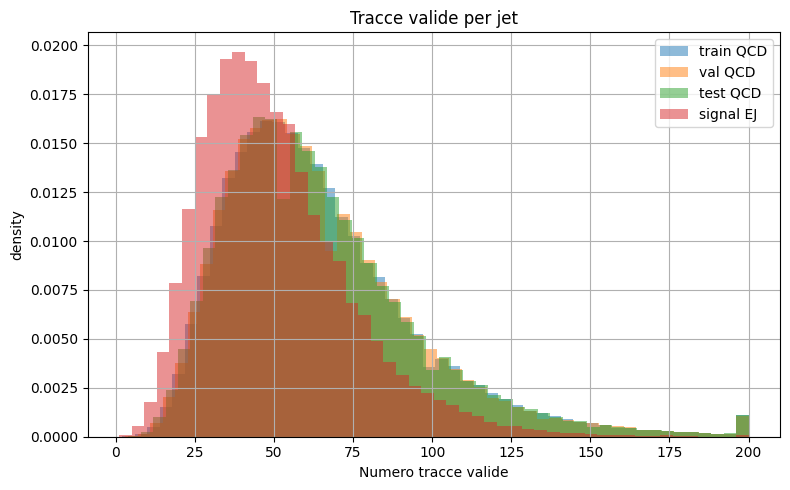

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(mask_train.sum(axis=1), bins=50, density=True, alpha=0.5, label="train QCD")
plt.hist(mask_val.sum(axis=1), bins=50, density=True, alpha=0.5, label="val QCD")
plt.hist(mask_bkg_test.sum(axis=1), bins=50, density=True, alpha=0.5, label="test QCD")
plt.hist(mask_sig.sum(axis=1), bins=50, density=True, alpha=0.5, label="signal EJ")
plt.xlabel("Numero tracce valide")
plt.ylabel("density")
plt.title("Tracce valide per jet")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "valid_tracks_distribution.png", dpi=200)
plt.show()

## 7. Dataset e DataLoader

In [16]:
class JetTrackSetDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(np.asarray(X_jets, dtype=np.float32))
        self.X_tracks = torch.from_numpy(np.asarray(X_tracks, dtype=np.float32))
        self.mask = torch.from_numpy(np.asarray(mask)).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        # Restituisco, per un singolo jet: feature del jet, sequenza di tracce padded e mask delle tracce valide.
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


BATCH_SIZE = 256

train_loader = DataLoader(
    JetTrackSetDataset(X_jets_train, X_tracks_train, mask_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    JetTrackSetDataset(X_jets_val, X_tracks_val, mask_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

center_loader = DataLoader(
    JetTrackSetDataset(X_jets_train, X_tracks_train, mask_train),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 782
Val batches: 391


## 8. Transformer Set Encoder

In [17]:
class TransformerSetEncoder(nn.Module):
    """
    Transformer Deep SVDD con attention pooling.

    Rispetto alla versione iniziale:
    - il Transformer fa self-attention tra le tracce dello stesso jet;
    - il pooling finale non è solo mean+max, ma include anche attention pooling;
    - il modello può essere scalato tramite d_model, n_layers, latent_dim e dropout;
    - salvo i pesi di attention per eventuale interpretabilità.
    """

    def __init__(
        self,
        n_track_features,
        n_jet_features,
        d_model=128,
        n_heads=8,
        n_layers=4,
        dim_feedforward=512,
        latent_dim=64,
        dropout=0.07,
    ):
        super().__init__()

        self.n_track_features = n_track_features
        self.n_jet_features = n_jet_features
        self.d_model = d_model
        self.latent_dim = latent_dim

        # Embedding iniziale delle tracce.
        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
        )

        # Self-attention tra le tracce.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # Encoder delle feature globali del jet.
        if n_jet_features > 0:
            self.jet_encoder = nn.Sequential(
                nn.Linear(n_jet_features, d_model),
                nn.LayerNorm(d_model),
                nn.SiLU(),
                nn.Dropout(dropout),

                nn.Linear(d_model, d_model),
                nn.LayerNorm(d_model),
                nn.SiLU(),
            )
        else:
            # Fallback robusto, nel caso non ci siano feature jet-level.
            self.jet_encoder = nn.Sequential(
                nn.Linear(1, d_model),
                nn.LayerNorm(d_model),
                nn.SiLU(),
                nn.Dropout(dropout),

                nn.Linear(d_model, d_model),
                nn.LayerNorm(d_model),
                nn.SiLU(),
            )

        # Attention pooling:
        # il modello impara un peso per ogni traccia valida.
        self.attn_pool = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Tanh(),
            nn.Linear(d_model, 1),
        )

        # mean_pool + max_pool + attention_pool + jet_h
        total_dim = 4 * d_model

        self.output = nn.Sequential(
            nn.Linear(total_dim, 2 * d_model),
            nn.LayerNorm(2 * d_model),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(2 * d_model, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(d_model, latent_dim),
        )

        self.last_attention_weights = None

    def forward(self, x_jets, x_tracks, mask):
        # x_jets:   [B, F_jet]
        # x_tracks: [B, N, F_track]
        # mask:     [B, N], True per tracce valide

        h = self.track_embed(x_tracks)

        # In PyTorch Transformer, True vuol dire posizione da ignorare.
        h = self.transformer(
            h,
            src_key_padding_mask=~mask,
        )

        mask_f = mask.unsqueeze(-1).float()
        valid_counts = mask_f.sum(dim=1).clamp_min(1.0)

        # 1. Mean pooling sulle tracce valide.
        mean_pool = (h * mask_f).sum(dim=1) / valid_counts

        # 2. Max pooling sulle tracce valide.
        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values
        max_pool = torch.where(
            torch.isfinite(max_pool),
            max_pool,
            torch.zeros_like(max_pool),
        )

        # 3. Attention pooling.
        attn_logits = self.attn_pool(h).squeeze(-1)
        attn_logits = attn_logits.masked_fill(~mask, -1e9)

        attn_weights = torch.softmax(attn_logits, dim=1)

        # Sicurezza numerica: padding a zero e rinormalizzazione.
        attn_weights = torch.where(
            mask,
            attn_weights,
            torch.zeros_like(attn_weights),
        )

        attn_weights = attn_weights / attn_weights.sum(
            dim=1,
            keepdim=True,
        ).clamp_min(1e-8)

        attn_pool = torch.sum(
            h * attn_weights.unsqueeze(-1),
            dim=1,
        )

        self.last_attention_weights = attn_weights.detach()

        if self.n_jet_features > 0:
            jet_h = self.jet_encoder(x_jets)
        else:
            dummy = torch.zeros((x_tracks.shape[0], 1), device=x_tracks.device)
            jet_h = self.jet_encoder(dummy)

        z = self.output(
            torch.cat(
                [
                    mean_pool,
                    max_pool,
                    attn_pool,
                    jet_h,
                ],
                dim=1,
            )
        )

        return z


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 9. Crea modello

In [18]:
# ============================================================
# Quick hyperparameter tuning — Transformer Deep SVDD
# ============================================================
# Criterio:
# - uso solo QCD train/validation;
# - il segnale EJ NON viene mai usato per scegliere gli iperparametri;
# - provo configurazioni diverse di architettura e training;
# - scelgo la configurazione con validation SVDD loss più bassa;
# - penalizzo leggermente overfitting e background inconsistency.
#
# ============================================================

import gc

RUN_TRANSFORMER_HPARAM_TUNING = True

TUNE_MAX_TRAIN = 10_000
TUNE_MAX_VAL = 8_000
TUNE_EPOCHS = 14
TUNE_PATIENCE = 4

# Se è troppo lento, lascia solo le prime 4 configurazioni.
CANDIDATE_CONFIGS = [
    {
        "d_model": 96,
        "n_heads": 4,
        "n_layers": 3,
        "dim_feedforward": 384,
        "latent_dim": 32,
        "dropout": 0.05,
        "lr": 1.0e-4,
        "weight_decay": 1e-5,
        "batch_size": 256,
    },
    {
        "d_model": 128,
        "n_heads": 8,
        "n_layers": 3,
        "dim_feedforward": 512,
        "latent_dim": 32,
        "dropout": 0.05,
        "lr": 8.0e-5,
        "weight_decay": 1e-5,
        "batch_size": 256,
    },
    {
        "d_model": 128,
        "n_heads": 8,
        "n_layers": 4,
        "dim_feedforward": 512,
        "latent_dim": 64,
        "dropout": 0.07,
        "lr": 7.0e-5,
        "weight_decay": 2e-5,
        "batch_size": 192,
    },
    {
        "d_model": 128,
        "n_heads": 8,
        "n_layers": 4,
        "dim_feedforward": 768,
        "latent_dim": 64,
        "dropout": 0.10,
        "lr": 6.0e-5,
        "weight_decay": 3e-5,
        "batch_size": 192,
    },
    {
        "d_model": 160,
        "n_heads": 8,
        "n_layers": 4,
        "dim_feedforward": 640,
        "latent_dim": 64,
        "dropout": 0.08,
        "lr": 5.0e-5,
        "weight_decay": 3e-5,
        "batch_size": 128,
    },
    {
        "d_model": 160,
        "n_heads": 8,
        "n_layers": 5,
        "dim_feedforward": 640,
        "latent_dim": 96,
        "dropout": 0.10,
        "lr": 5.0e-5,
        "weight_decay": 5e-5,
        "batch_size": 128,
    },
    {
        "d_model": 192,
        "n_heads": 8,
        "n_layers": 4,
        "dim_feedforward": 768,
        "latent_dim": 64,
        "dropout": 0.10,
        "lr": 4.0e-5,
        "weight_decay": 5e-5,
        "batch_size": 96,
    },
]


def _subsample_triplet(Xj, Xt, M, max_n, seed):
    n = len(Xt)
    if n <= max_n:
        return Xj, Xt, M

    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_n, replace=False)

    return Xj[idx], Xt[idx], M[idx]


Xj_tune_train, Xt_tune_train, M_tune_train = _subsample_triplet(
    X_jets_train,
    X_tracks_train,
    mask_train,
    TUNE_MAX_TRAIN,
    SEED,
)

Xj_tune_val, Xt_tune_val, M_tune_val = _subsample_triplet(
    X_jets_val,
    X_tracks_val,
    mask_val,
    TUNE_MAX_VAL,
    SEED + 1,
)

print("Tuning train:", Xj_tune_train.shape, Xt_tune_train.shape)
print("Tuning val:", Xj_tune_val.shape, Xt_tune_val.shape)


def make_tune_loader(Xj, Xt, M, batch_size, shuffle=False):
    return DataLoader(
        JetTrackSetDataset(Xj, Xt, M),
        batch_size=int(batch_size),
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


@torch.no_grad()
def tune_compute_center(model, loader, eps=1e-6):
    model.eval()

    zs = []

    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask)
        zs.append(z.detach().cpu())

    z_all = torch.cat(zs, dim=0)
    center_local = z_all.mean(dim=0).to(device)

    center_local[(torch.abs(center_local) < eps) & (center_local < 0)] = -eps
    center_local[(torch.abs(center_local) < eps) & (center_local >= 0)] = eps

    return center_local


def tune_svdd_loss(z, center_local):
    dist2 = torch.sum((z - center_local.unsqueeze(0)) ** 2, dim=1)
    return dist2.mean(), dist2


@torch.no_grad()
def tune_eval_loss(model, loader, center_local):
    model.eval()

    total = 0.0
    n = 0

    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask)
        loss, _ = tune_svdd_loss(z, center_local)

        total += loss.item() * x_jets.shape[0]
        n += x_jets.shape[0]

    return total / max(n, 1)


@torch.no_grad()
def tune_scores_and_latents(model, loader, center_local):
    model.eval()

    scores = []
    latents = []

    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask)
        score = torch.sum((z - center_local.unsqueeze(0)) ** 2, dim=1)

        scores.append(score.detach().cpu().numpy())
        latents.append(z.detach().cpu().numpy())

    return np.concatenate(scores), np.concatenate(latents, axis=0)


def tune_one_transformer_config(cfg, config_id):
    print("\n" + "=" * 90)
    print(f"TRANSFORMER CONFIG {config_id}/{len(CANDIDATE_CONFIGS)}")
    print(cfg)

    train_l = make_tune_loader(
        Xj_tune_train,
        Xt_tune_train,
        M_tune_train,
        cfg["batch_size"],
        shuffle=True,
    )

    val_l = make_tune_loader(
        Xj_tune_val,
        Xt_tune_val,
        M_tune_val,
        cfg["batch_size"],
        shuffle=False,
    )

    center_l = make_tune_loader(
        Xj_tune_train,
        Xt_tune_train,
        M_tune_train,
        cfg["batch_size"],
        shuffle=False,
    )

    model_tune = TransformerSetEncoder(
        n_track_features=n_track_features,
        n_jet_features=n_jet_features,
        d_model=int(cfg["d_model"]),
        n_heads=int(cfg["n_heads"]),
        n_layers=int(cfg["n_layers"]),
        dim_feedforward=int(cfg["dim_feedforward"]),
        latent_dim=int(cfg["latent_dim"]),
        dropout=float(cfg["dropout"]),
    ).to(device)

    n_params = count_params(model_tune)

    center_local = tune_compute_center(model_tune, center_l)

    optimizer_tune = torch.optim.AdamW(
        model_tune.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"]),
    )

    scheduler_tune = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_tune,
        mode="min",
        factor=0.5,
        patience=2,
    )

    best_val = np.inf
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, TUNE_EPOCHS + 1):
        model_tune.train()

        train_losses = []

        for x_jets, x_tracks, mask in train_l:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            optimizer_tune.zero_grad()

            z = model_tune(x_jets, x_tracks, mask)
            loss, _ = tune_svdd_loss(z, center_local)

            if not torch.isfinite(loss):
                raise RuntimeError("Transformer tuning loss non finita")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tune.parameters(), max_norm=5.0)
            optimizer_tune.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = tune_eval_loss(model_tune, val_l, center_local)

        scheduler_tune.step(val_loss)

        print(
            f"epoch {epoch:02d}/{TUNE_EPOCHS} | "
            f"train={train_loss:.6f} | "
            f"val={val_loss:.6f} | "
            f"best={best_val:.6f}"
        )

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model_tune.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= TUNE_PATIENCE:
            print("early stopping tuning")
            break

    if best_state is not None:
        model_tune.load_state_dict(best_state)

    train_loss_final = tune_eval_loss(model_tune, train_l, center_local)
    val_loss_final = tune_eval_loss(model_tune, val_l, center_local)

    train_scores, train_latents = tune_scores_and_latents(model_tune, train_l, center_local)
    val_scores, val_latents = tune_scores_and_latents(model_tune, val_l, center_local)

    # Background consistency train QCD vs val QCD.
    y_bg = np.concatenate([
        np.zeros_like(train_scores),
        np.ones_like(val_scores),
    ])

    s_bg = np.concatenate([
        train_scores,
        val_scores,
    ])

    bg_auc = roc_auc_score(y_bg, s_bg)
    bg_auc_inv = roc_auc_score(y_bg, -s_bg)
    bg_auc_best = max(bg_auc, bg_auc_inv)

    latent_std_mean = float(np.mean(np.std(train_latents, axis=0)))
    latent_std_min = float(np.min(np.std(train_latents, axis=0)))

    gap = max(0.0, val_loss_final - train_loss_final)

    # Criterio finale:
    # - val loss bassa;
    # - piccolo penalty se train/val QCD sono troppo separabili;
    # - piccolo penalty se il latent collassa.
    bg_penalty = max(0.0, bg_auc_best - 0.55) * val_loss_final
    gap_penalty = 0.30 * gap
    collapse_penalty = 0.0 if latent_std_mean >= 1e-3 else 10.0 * val_loss_final

    selection_score = best_val + bg_penalty + gap_penalty + collapse_penalty

    result = {
        "config_id": int(config_id),
        **cfg,
        "n_params": int(n_params),
        "best_epoch": int(best_epoch),
        "train_loss": float(train_loss_final),
        "val_loss": float(val_loss_final),
        "generalization_gap": float(gap),
        "bg_auc_train_vs_val": float(bg_auc),
        "bg_auc_train_vs_val_inverted": float(bg_auc_inv),
        "bg_auc_train_vs_val_best": float(bg_auc_best),
        "latent_std_mean": float(latent_std_mean),
        "latent_std_min": float(latent_std_min),
        "selection_score": float(selection_score),
    }

    del model_tune
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


if RUN_TRANSFORMER_HPARAM_TUNING:
    transformer_tuning_rows = []

    for i, cfg in enumerate(CANDIDATE_CONFIGS, start=1):
        try:
            transformer_tuning_rows.append(tune_one_transformer_config(cfg, i))
        except RuntimeError as e:
            print(f"[SKIP CONFIG {i}] RuntimeError:", e)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    transformer_tuning_results_df = pd.DataFrame(transformer_tuning_rows)

    transformer_tuning_results_df = transformer_tuning_results_df.sort_values(
        "selection_score",
        ascending=True,
    ).reset_index(drop=True)

    display(transformer_tuning_results_df)

    transformer_tuning_results_df.to_csv(
        OUTPUT_DIR / "transformer_deep_svdd_hparam_tuning.csv",
        index=False,
    )

    print("Saved:", OUTPUT_DIR / "transformer_deep_svdd_hparam_tuning.csv")

    BEST_TRANSFORMER_CONFIG = transformer_tuning_results_df.iloc[0].to_dict()

else:
    BEST_TRANSFORMER_CONFIG = {
        "d_model": 128,
        "n_heads": 8,
        "n_layers": 4,
        "dim_feedforward": 512,
        "latent_dim": 64,
        "dropout": 0.07,
        "lr": 7e-5,
        "weight_decay": 2e-5,
        "batch_size": 192,
    }

print("\n" + "=" * 90)
print("BEST TRANSFORMER CONFIG")
print(BEST_TRANSFORMER_CONFIG)

# Variabili globali per il training finale.
D_MODEL = int(BEST_TRANSFORMER_CONFIG["d_model"])
N_HEADS = int(BEST_TRANSFORMER_CONFIG["n_heads"])
N_LAYERS = int(BEST_TRANSFORMER_CONFIG["n_layers"])
DIM_FEEDFORWARD = int(BEST_TRANSFORMER_CONFIG["dim_feedforward"])
LATENT_DIM = int(BEST_TRANSFORMER_CONFIG["latent_dim"])
DROPOUT = float(BEST_TRANSFORMER_CONFIG["dropout"])

LR = float(BEST_TRANSFORMER_CONFIG["lr"])
WEIGHT_DECAY = float(BEST_TRANSFORMER_CONFIG["weight_decay"])
BATCH_SIZE = int(BEST_TRANSFORMER_CONFIG["batch_size"])

N_EPOCHS = 120
PATIENCE = 18

print("\nIperparametri finali impostati:")
print("D_MODEL        =", D_MODEL)
print("N_HEADS        =", N_HEADS)
print("N_LAYERS       =", N_LAYERS)
print("DIM_FEEDFORWARD=", DIM_FEEDFORWARD)
print("LATENT_DIM     =", LATENT_DIM)
print("DROPOUT        =", DROPOUT)
print("LR             =", LR)
print("WEIGHT_DECAY   =", WEIGHT_DECAY)
print("BATCH_SIZE     =", BATCH_SIZE)
print("N_EPOCHS       =", N_EPOCHS)
print("PATIENCE       =", PATIENCE)

Tuning train: (10000, 15) (10000, 200, 16)
Tuning val: (8000, 15) (8000, 200, 16)

TRANSFORMER CONFIG 1/7
{'d_model': 96, 'n_heads': 4, 'n_layers': 3, 'dim_feedforward': 384, 'latent_dim': 32, 'dropout': 0.05, 'lr': 0.0001, 'weight_decay': 1e-05, 'batch_size': 256}
epoch 01/14 | train=0.321937 | val=0.011658 | best=inf
epoch 02/14 | train=0.160768 | val=0.005054 | best=0.011658
epoch 03/14 | train=0.115334 | val=0.003974 | best=0.005054
epoch 04/14 | train=0.087944 | val=0.003091 | best=0.003974
epoch 05/14 | train=0.072349 | val=0.001725 | best=0.003091
epoch 06/14 | train=0.060224 | val=0.001595 | best=0.001725
epoch 07/14 | train=0.051944 | val=0.001502 | best=0.001595
epoch 08/14 | train=0.045514 | val=0.001145 | best=0.001502
epoch 09/14 | train=0.041091 | val=0.000767 | best=0.001145
epoch 10/14 | train=0.036932 | val=0.000877 | best=0.000767
epoch 11/14 | train=0.033294 | val=0.000793 | best=0.000767
epoch 12/14 | train=0.030552 | val=0.000643 | best=0.000767
epoch 13/14 | train

,config_id,d_model,n_heads,n_layers,dim_feedforward,latent_dim,dropout,lr,weight_decay,batch_size,...,best_epoch,train_loss,val_loss,generalization_gap,bg_auc_train_vs_val,bg_auc_train_vs_val_inverted,bg_auc_train_vs_val_best,latent_std_mean,latent_std_min,selection_score
0,2,128,8,3,512,32,0.05,0.00008,0.00001,256,...,14,0.000534,0.000532,0.000000e+00,0.497037,0.502963,0.502963,0.002521,0.002068,0.000532
1,1,96,4,3,384,32,0.05,0.00010,0.00001,256,...,14,0.000565,0.000569,3.376516e-06,0.504663,0.495337,0.504663,0.002553,0.002011,0.000570
2,7,192,8,4,768,64,0.10,0.00004,0.00005,96,...,14,0.000627,0.000627,0.000000e+00,0.501294,0.498706,0.501294,0.001328,0.001132,0.000627
3,3,128,8,4,512,64,0.07,0.00007,0.00002,192,...,14,0.000761,0.000761,0.000000e+00,0.500121,0.499879,0.500121,0.001881,0.001441,0.000761
4,5,160,8,4,640,64,0.08,0.00005,0.00003,128,...,14,0.001078,0.001076,0.000000e+00,0.496796,0.503204,0.503204,0.001671,0.001345,0.001076
5,4,128,8,4,768,64,0.10,0.00006,0.00003,192,...,13,0.002084,0.002087,2.693141e-06,0.502778,0.497222,0.502778,0.002198,0.001771,0.002087
6,6,160,8,5,640,96,0.10,0.00005,0.00005,128,...,13,0.002128,0.002129,9.409115e-08,0.500226,0.499774,0.500226,0.001445,0.001083,0.002129


Saved: ..\outputs\transformer_deep_svdd\transformer_deep_svdd_hparam_tuning.csv

BEST TRANSFORMER CONFIG
{'config_id': 2.0, 'd_model': 128.0, 'n_heads': 8.0, 'n_layers': 3.0, 'dim_feedforward': 512.0, 'latent_dim': 32.0, 'dropout': 0.05, 'lr': 8e-05, 'weight_decay': 1e-05, 'batch_size': 256.0, 'n_params': 818849.0, 'best_epoch': 14.0, 'train_loss': 0.0005340715494938195, 'val_loss': 0.0005323510635644197, 'generalization_gap': 0.0, 'bg_auc_train_vs_val': 0.49703670625, 'bg_auc_train_vs_val_inverted': 0.5029632937499999, 'bg_auc_train_vs_val_best': 0.5029632937499999, 'latent_std_mean': 0.0025205269921571016, 'latent_std_min': 0.0020682127214968204, 'selection_score': 0.0005323510635644197}

Iperparametri finali impostati:
D_MODEL        = 128
N_HEADS        = 8
N_LAYERS       = 3
DIM_FEEDFORWARD= 512
LATENT_DIM     = 32
DROPOUT        = 0.05
LR             = 8e-05
WEIGHT_DECAY   = 1e-05
BATCH_SIZE     = 256
N_EPOCHS       = 120
PATIENCE       = 18


## 9.1 Plot tuning Transformer in stile gomito

Il criterio è sempre: più basso è meglio. Il segnale EJ non è usato nel tuning.


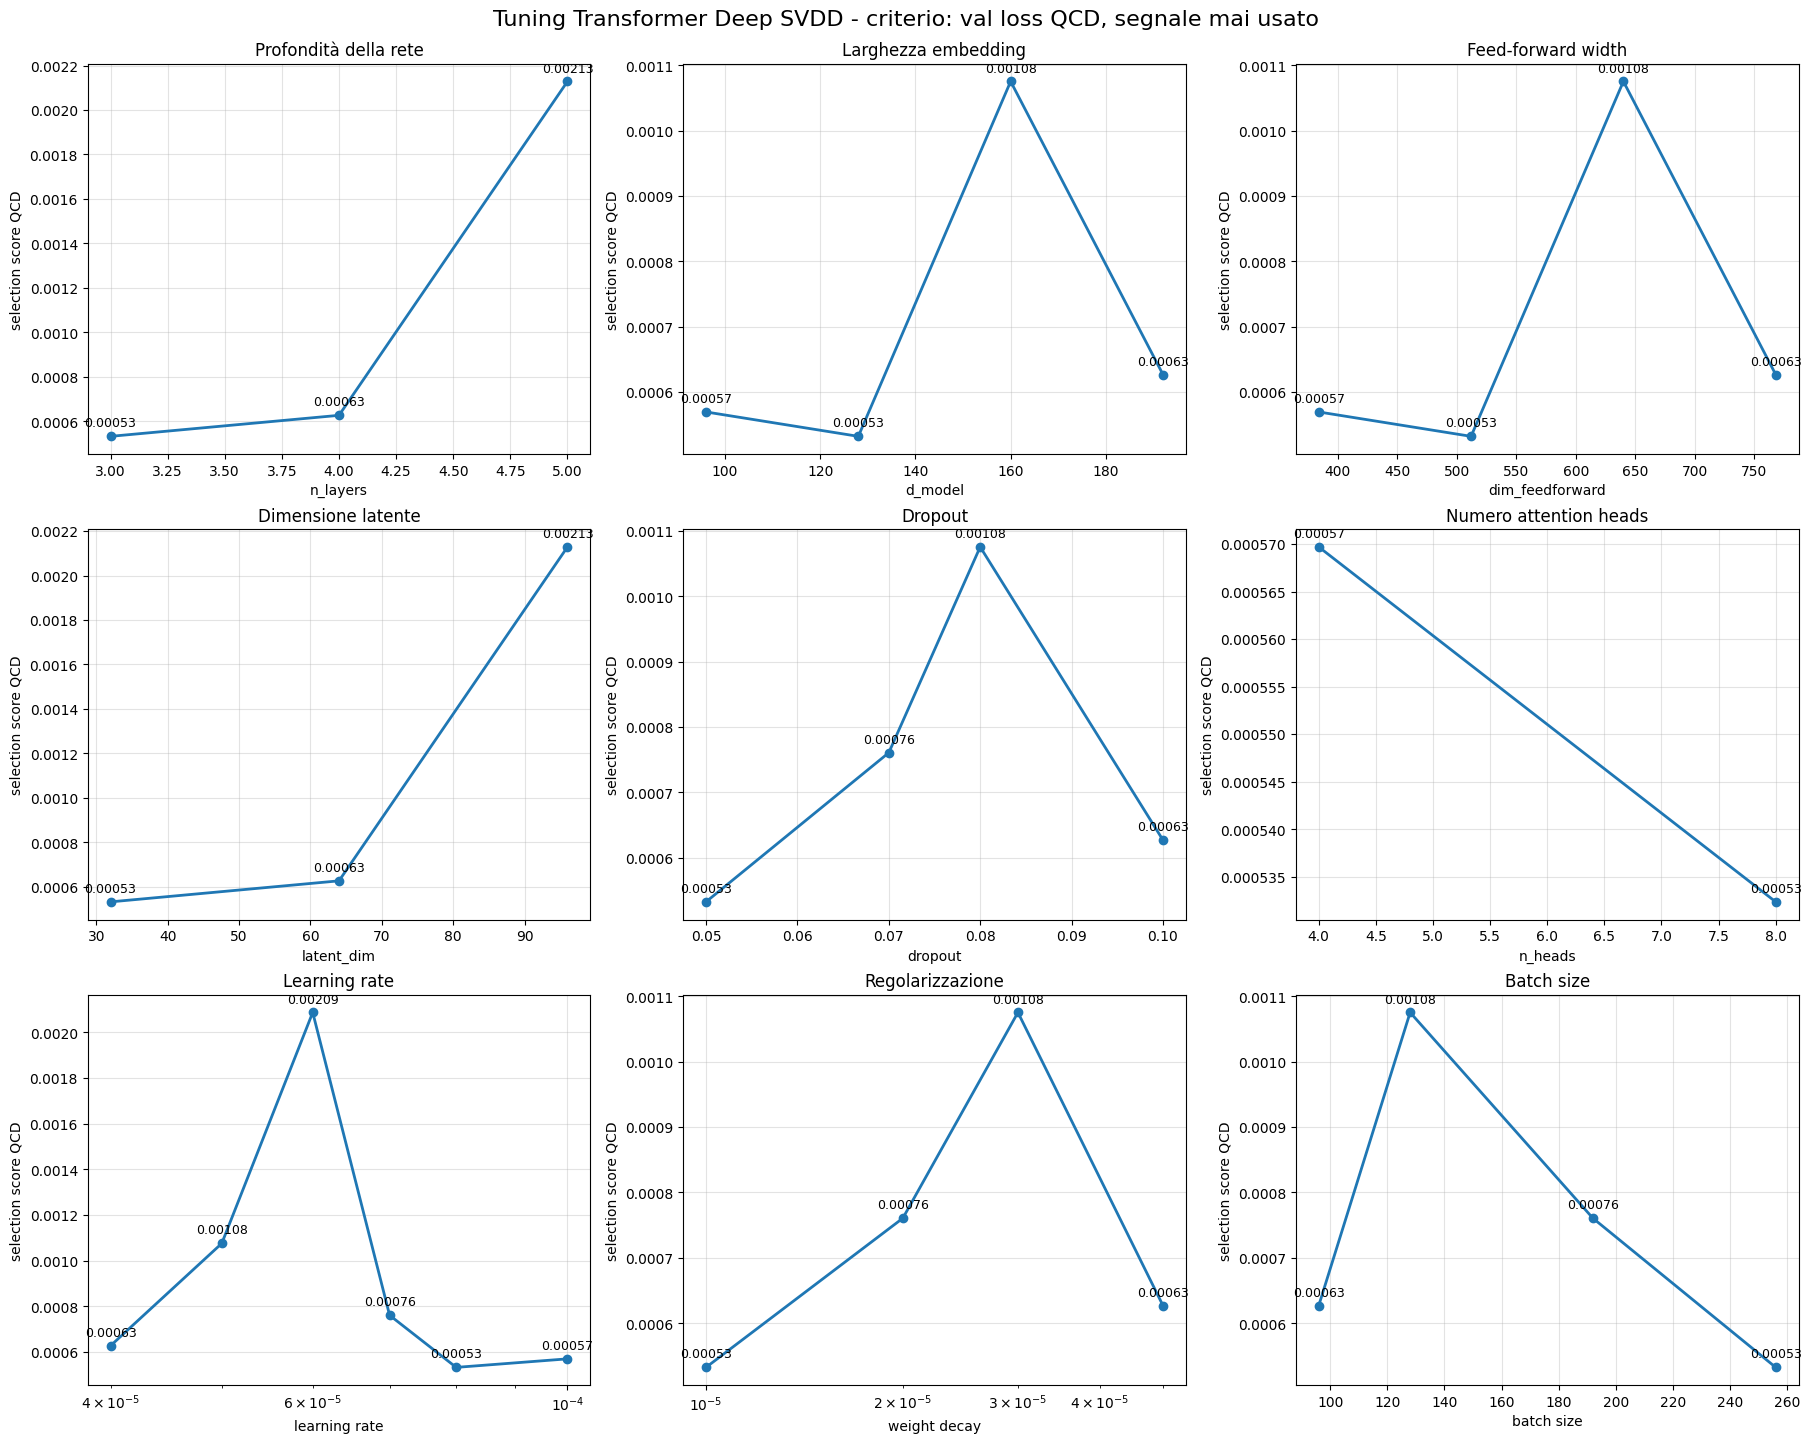

Salvato: ..\outputs\transformer_deep_svdd\plots\transformer_deep_svdd_hparam_elbow_plots.png


,config_id,d_model,n_heads,n_layers,dim_feedforward,latent_dim,dropout,lr,weight_decay,batch_size,...,best_epoch,train_loss,val_loss,generalization_gap,bg_auc_train_vs_val,bg_auc_train_vs_val_inverted,bg_auc_train_vs_val_best,latent_std_mean,latent_std_min,selection_score
0,2,128,8,3,512,32,0.05,0.00008,0.00001,256,...,14,0.000534,0.000532,0.000000e+00,0.497037,0.502963,0.502963,0.002521,0.002068,0.000532
1,1,96,4,3,384,32,0.05,0.00010,0.00001,256,...,14,0.000565,0.000569,3.376516e-06,0.504663,0.495337,0.504663,0.002553,0.002011,0.000570
2,7,192,8,4,768,64,0.10,0.00004,0.00005,96,...,14,0.000627,0.000627,0.000000e+00,0.501294,0.498706,0.501294,0.001328,0.001132,0.000627
3,3,128,8,4,512,64,0.07,0.00007,0.00002,192,...,14,0.000761,0.000761,0.000000e+00,0.500121,0.499879,0.500121,0.001881,0.001441,0.000761
4,5,160,8,4,640,64,0.08,0.00005,0.00003,128,...,14,0.001078,0.001076,0.000000e+00,0.496796,0.503204,0.503204,0.001671,0.001345,0.001076
5,4,128,8,4,768,64,0.10,0.00006,0.00003,192,...,13,0.002084,0.002087,2.693141e-06,0.502778,0.497222,0.502778,0.002198,0.001771,0.002087
6,6,160,8,5,640,96,0.10,0.00005,0.00005,128,...,13,0.002128,0.002129,9.409115e-08,0.500226,0.499774,0.500226,0.001445,0.001083,0.002129


In [19]:
# ============================================================
# Plot tuning Transformer 
# ============================================================

try:
    df_tf_tune = transformer_tuning_results_df.copy()
except NameError:
    df_tf_tune = pd.read_csv(OUTPUT_DIR / "transformer_deep_svdd_hparam_tuning.csv")

Y_COL = "selection_score"
Y_LABEL = "selection score QCD"

def best_by_param(data, param):
    return (
        data
        .groupby(param, as_index=False)[Y_COL]
        .min()
        .sort_values(param)
        .reset_index(drop=True)
    )

def plot_line_with_labels(ax, x, y, xlabel, title, logx=False):
    ax.plot(x, y, marker="o", linewidth=2)

    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.5f}",
            xy=(xi, yi),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(Y_LABEL)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)

    if logx:
        ax.set_xscale("log")

fig, axes = plt.subplots(
    3,
    3,
    figsize=(18, 14),
    constrained_layout=True,
)

axes = axes.flatten()

fig.suptitle(
    "Tuning Transformer Deep SVDD - criterio: val loss QCD, segnale mai usato",
    fontsize=16,
    y=1.02,
)

for ax, param, xlabel, title, logx in [
    (axes[0], "n_layers", "n_layers", "Profondità della rete", False),
    (axes[1], "d_model", "d_model", "Larghezza embedding", False),
    (axes[2], "dim_feedforward", "dim_feedforward", "Feed-forward width", False),

    (axes[3], "latent_dim", "latent_dim", "Dimensione latente", False),
    (axes[4], "dropout", "dropout", "Dropout", False),
    (axes[5], "n_heads", "n_heads", "Numero attention heads", False),

    (axes[6], "lr", "learning rate", "Learning rate", True),
    (axes[7], "weight_decay", "weight decay", "Regolarizzazione", True),
    (axes[8], "batch_size", "batch size", "Batch size", False),
]:
    g = best_by_param(df_tf_tune, param)

    plot_line_with_labels(
        ax,
        g[param],
        g[Y_COL],
        xlabel,
        title,
        logx=logx,
    )

out_path = PLOTS_DIR / "transformer_deep_svdd_hparam_elbow_plots.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Salvato:", out_path)
display(df_tf_tune.sort_values("selection_score").reset_index(drop=True))

## 9.2 Creazione modello finale

Da qui in poi il notebook riprende il training completo con la configurazione migliore scelta sul QCD.


In [20]:
# ============================================================
# Creazione modello finale con configurazione scelta dal tuning
# ============================================================

if "BEST_TRANSFORMER_CONFIG" in globals():
    print("Uso configurazione scelta dal tuning.")

    D_MODEL = int(BEST_TRANSFORMER_CONFIG["d_model"])
    N_HEADS = int(BEST_TRANSFORMER_CONFIG["n_heads"])
    N_LAYERS = int(BEST_TRANSFORMER_CONFIG["n_layers"])
    DIM_FEEDFORWARD = int(BEST_TRANSFORMER_CONFIG["dim_feedforward"])
    LATENT_DIM = int(BEST_TRANSFORMER_CONFIG["latent_dim"])
    DROPOUT = float(BEST_TRANSFORMER_CONFIG["dropout"])

    LR = float(BEST_TRANSFORMER_CONFIG["lr"])
    WEIGHT_DECAY = float(BEST_TRANSFORMER_CONFIG["weight_decay"])
    BATCH_SIZE = int(BEST_TRANSFORMER_CONFIG["batch_size"])

else:
    print("BEST_TRANSFORMER_CONFIG non trovata: uso configurazione standard attention v2.")

    D_MODEL = 128
    N_HEADS = 8
    N_LAYERS = 4
    DIM_FEEDFORWARD = 512
    LATENT_DIM = 64
    DROPOUT = 0.07

    LR = 7e-5
    WEIGHT_DECAY = 2e-5
    BATCH_SIZE = 192

N_EPOCHS = 120
PATIENCE = 18

# Ricreo i DataLoader finali con il batch size scelto.
train_loader = DataLoader(
    JetTrackSetDataset(X_jets_train, X_tracks_train, mask_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    JetTrackSetDataset(X_jets_val, X_tracks_val, mask_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

center_loader = DataLoader(
    JetTrackSetDataset(X_jets_train, X_tracks_train, mask_train),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

model = TransformerSetEncoder(
    n_track_features=n_track_features,
    n_jet_features=n_jet_features,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    latent_dim=LATENT_DIM,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=6,
)

print(model)
print("Parameters:", count_params(model))
print()
print("Final Transformer config:")
print("D_MODEL        =", D_MODEL)
print("N_HEADS        =", N_HEADS)
print("N_LAYERS       =", N_LAYERS)
print("DIM_FEEDFORWARD=", DIM_FEEDFORWARD)
print("LATENT_DIM     =", LATENT_DIM)
print("DROPOUT        =", DROPOUT)
print("LR             =", LR)
print("WEIGHT_DECAY   =", WEIGHT_DECAY)
print("BATCH_SIZE     =", BATCH_SIZE)
print("Train batches  =", len(train_loader))
print("Val batches    =", len(val_loader))

Uso configurazione scelta dal tuning.
TransformerSetEncoder(
  (track_embed): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (6): SiLU()
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.05, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine

## 10. Inizializzazione centro SVDD

In [21]:
@torch.no_grad()
def compute_center(model, loader, eps=1e-6):
    model.eval()

    zs = []

    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask)
        zs.append(z.cpu())

    z_all = torch.cat(zs, dim=0)
    c = z_all.mean(dim=0)

    # Evita coordinate esattamente zero, come spesso consigliato in Deep SVDD.
    c[(torch.abs(c) < eps) & (c < 0)] = -eps
    c[(torch.abs(c) < eps) & (c >= 0)] = eps

    return c.to(device)


center = compute_center(model, center_loader)

print("center shape:", center.shape)
print("center mean/std:", center.mean().item(), center.std().item())
print("center min/max:", center.min().item(), center.max().item())

center shape: torch.Size([32])
center mean/std: -0.06874655932188034 0.31582048535346985
center min/max: -0.5731534957885742 0.571402370929718


## 11. Loss e training Deep SVDD

In [22]:
def svdd_loss(z, center):
    dist2 = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
    return dist2.mean(), dist2


def evaluate_svdd(model, loader, center):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for x_jets, x_tracks, mask in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            z = model(x_jets, x_tracks, mask)
            loss, _ = svdd_loss(z, center)

            bs = x_jets.shape[0]
            total_loss += loss.item() * bs
            total_items += bs

    return total_loss / max(total_items, 1)

In [23]:
train_losses = []
val_losses = []
lr_history = []

best_val_loss = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(N_EPOCHS):
    model.train()

    total_loss = 0.0
    total_items = 0

    for x_jets, x_tracks, mask in train_loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        optimizer.zero_grad()

        z = model(x_jets, x_tracks, mask)
        loss, _ = svdd_loss(z, center)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_items += bs

    train_loss = total_loss / max(total_items, 1)
    val_loss = evaluate_svdd(model, val_loader, center)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
        f"train={train_loss:.6f} | "
        f"val={val_loss:.6f} | "
        f"best={best_val_loss:.6f} @ {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val_loss:.6f}")

df_history = pd.DataFrame({
    "epoch": np.arange(1, len(train_losses) + 1),
    "train_svdd_loss": train_losses,
    "val_svdd_loss": val_losses,
    "lr": lr_history,
})

df_history.to_csv(OUTPUT_DIR / "transformer_deep_svdd_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "transformer_deep_svdd_training_history.csv")

Epoch 001/120 | train=0.066228 | val=0.000490 | best=0.000490 @ 1 | lr=8.00e-05
Epoch 002/120 | train=0.014068 | val=0.000505 | best=0.000490 @ 1 | lr=8.00e-05
Epoch 003/120 | train=0.007518 | val=0.000059 | best=0.000059 @ 3 | lr=8.00e-05
Epoch 004/120 | train=0.004718 | val=0.000181 | best=0.000059 @ 3 | lr=8.00e-05
Epoch 005/120 | train=0.003320 | val=0.000028 | best=0.000028 @ 5 | lr=8.00e-05
Epoch 006/120 | train=0.002539 | val=0.000086 | best=0.000028 @ 5 | lr=8.00e-05
Epoch 007/120 | train=0.002021 | val=0.000014 | best=0.000014 @ 7 | lr=8.00e-05
Epoch 008/120 | train=0.001678 | val=0.000030 | best=0.000014 @ 7 | lr=8.00e-05
Epoch 009/120 | train=0.001409 | val=0.000007 | best=0.000007 @ 9 | lr=8.00e-05
Epoch 010/120 | train=0.001206 | val=0.000003 | best=0.000003 @ 10 | lr=8.00e-05
Epoch 011/120 | train=0.001046 | val=0.000033 | best=0.000003 @ 10 | lr=8.00e-05
Epoch 012/120 | train=0.000920 | val=0.000074 | best=0.000003 @ 10 | lr=8.00e-05
Epoch 013/120 | train=0.000813 | val=

KeyboardInterrupt: 

## 12. Training plots

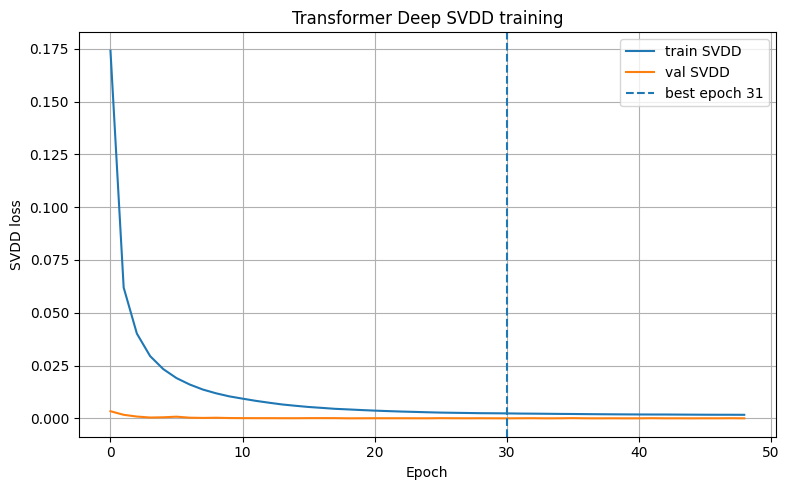

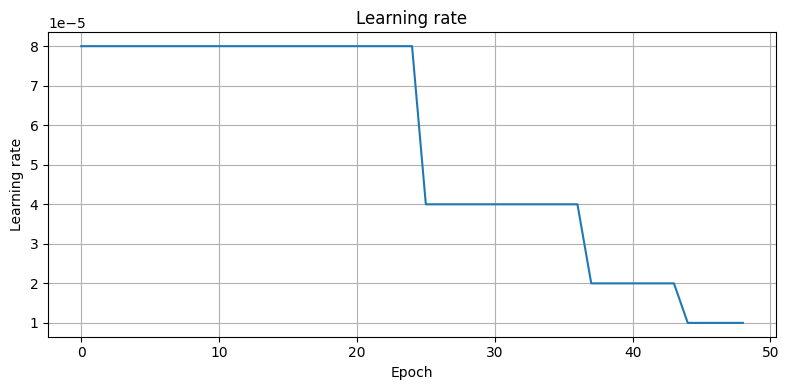

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train SVDD")
plt.plot(val_losses, label="val SVDD")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("SVDD loss")
plt.title("Transformer Deep SVDD training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_lr_schedule.png", dpi=200)
plt.show()

## 13. Calcolo score SVDD

In [ ]:
#non aggiorniamo i pesi
@torch.no_grad()
def compute_svdd_scores(model, X_jets, X_tracks, mask, center, batch_size=1024):
    dataset = JetTrackSetDataset(X_jets, X_tracks, mask)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    scores = []
    embeddings = []

    for x_jets, x_tracks, mask_batch in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask_batch)
        dist2 = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)

        scores.append(dist2.cpu().numpy())
        embeddings.append(z.cpu().numpy())

    return np.concatenate(scores), np.concatenate(embeddings, axis=0)


scores_train, Z_train = compute_svdd_scores(model, X_jets_train, X_tracks_train, mask_train, center)
scores_val, Z_val = compute_svdd_scores(model, X_jets_val, X_tracks_val, mask_val, center)
scores_bkg_test, Z_bkg_test = compute_svdd_scores(model, X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test, center)
scores_sig, Z_sig = compute_svdd_scores(model, X_jets_sig, X_tracks_sig, mask_sig, center)

for name, s in [
    ("train QCD", scores_train),
    ("val QCD", scores_val),
    ("test QCD", scores_bkg_test),
    ("signal EJ", scores_sig),
]:
    print(name, "mean", float(np.mean(s)), "std", float(np.std(s)), "q", np.percentile(s, [1, 50, 99]))

train QCD mean 9.083389159059152e-06 std 2.5327424282295397e-06 q [4.65655226e-06 8.75217120e-06 1.67547619e-05]
val QCD mean 9.079306437342893e-06 std 2.563909902164596e-06 q [4.65154691e-06 8.73891076e-06 1.68242689e-05]
test QCD mean 9.08835409063613e-06 std 2.5654121600382496e-06 q [4.66475457e-06 8.74087436e-06 1.70478207e-05]
signal EJ mean 1.6810459783300757e-05 std 7.708464181632735e-06 q [6.19193136e-06 1.51698496e-05 4.26185463e-05]


## 14. ROC/AUC e metriche a mistag fissato

In [ ]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name="Transformer Deep SVDD", score_name="SVDD"):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": model_name,
            "score": score_name,
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


eval_main = evaluate_scores(scores_bkg_test, scores_sig)

print("AUC:", eval_main["auc"])
print("AUC inverted:", eval_main["auc_inverted"])
print("Best AUC:", eval_main["best_auc"])
print("Flipped:", eval_main["flipped"])

display(eval_main["eff_table"])

AUC: 0.8707633643749999
AUC inverted: 0.12923663562499998
Best AUC: 0.8707633643749999
Flipped: False


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,Transformer Deep SVDD,SVDD,0.870763,0.870763,0.129237,False,0.300,0.300,0.841475,0.000010
1,Transformer Deep SVDD,SVDD,0.870763,0.870763,0.129237,False,0.100,0.100,0.692725,0.000012
2,Transformer Deep SVDD,SVDD,0.870763,0.870763,0.129237,False,0.050,0.050,0.598600,0.000014
3,Transformer Deep SVDD,SVDD,0.870763,0.870763,0.129237,False,0.010,0.010,0.392050,0.000017
4,Transformer Deep SVDD,SVDD,0.870763,0.870763,0.129237,False,0.001,0.001,0.204400,0.000022


## 15. Plot ROC, score distribution, efficiency vs mistag

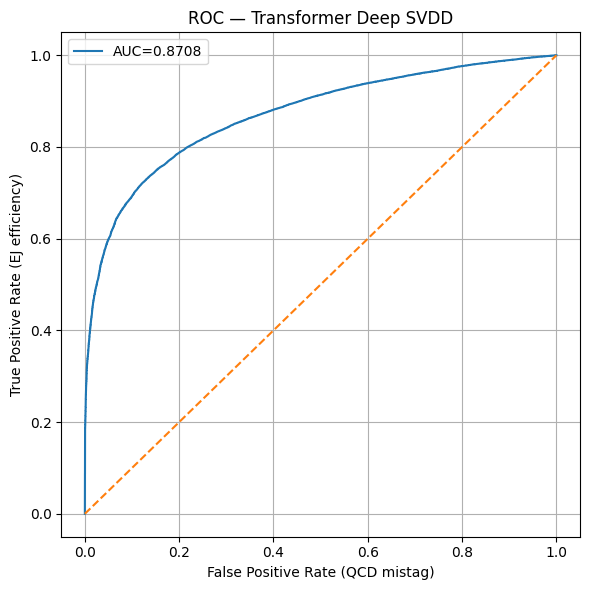

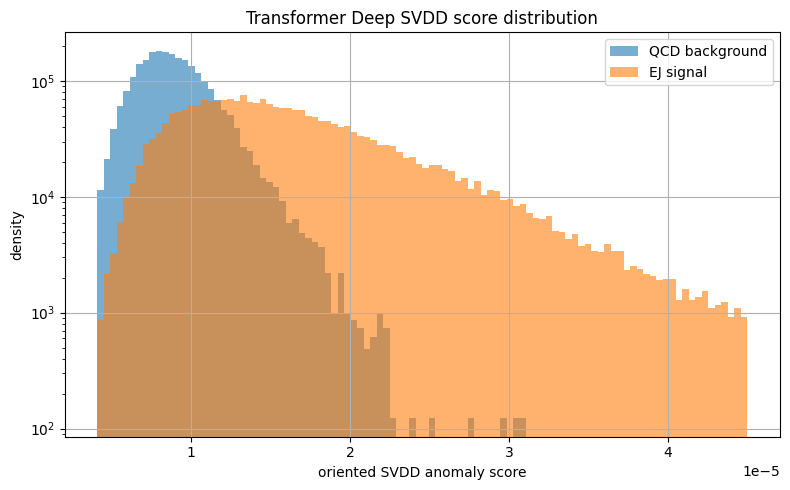

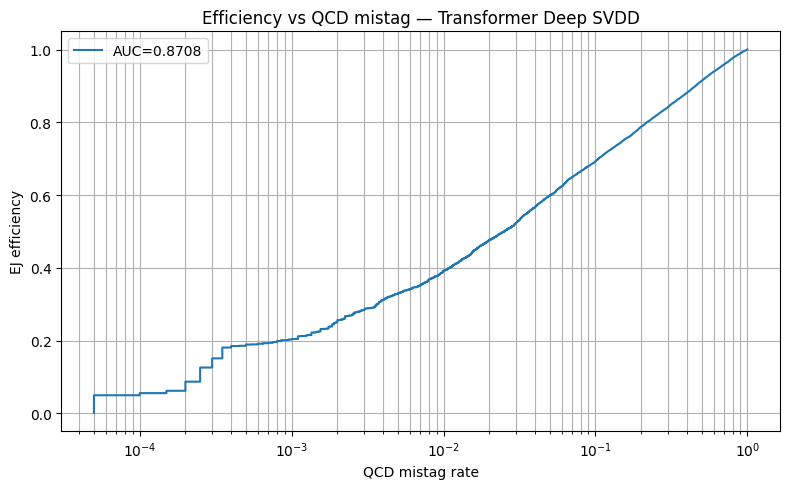

In [ ]:
bg_o = eval_main["bg_oriented"]
sig_o = eval_main["sig_oriented"]

plt.figure(figsize=(6, 6))
plt.plot(eval_main["fpr"], eval_main["tpr"], label=f"AUC={eval_main['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("ROC — Transformer Deep SVDD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_roc.png", dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
plt.yscale("log")
plt.xlabel("oriented SVDD anomaly score")
plt.ylabel("density")
plt.title("Transformer Deep SVDD score distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_score_distribution.png", dpi=200)
plt.show()

fpr = eval_main["fpr"]
tpr = eval_main["tpr"]
mask_fpr = fpr > 0

plt.figure(figsize=(8, 5))
plt.plot(fpr[mask_fpr], tpr[mask_fpr], label=f"AUC={eval_main['best_auc']:.4f}")
plt.xscale("log")
plt.xlabel("QCD mistag rate")
plt.ylabel("EJ efficiency")
plt.title("Efficiency vs QCD mistag — Transformer Deep SVDD")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_efficiency_vs_mistag.png", dpi=200)
plt.show()

## 16. Background consistency checks

,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.498999,0.501001,0.501001
1,train QCD vs test QCD,0.499562,0.500438,0.500438
2,val QCD vs test QCD,0.500547,0.499453,0.500547


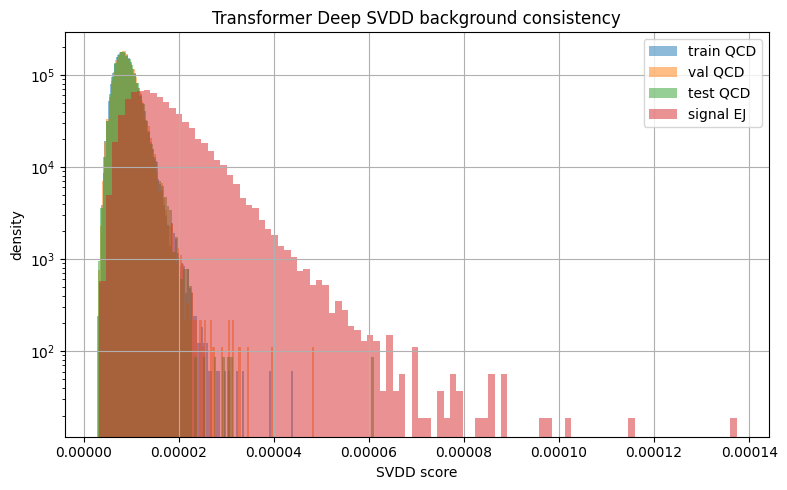

In [ ]:
#vogliamo anche qui 0.5
def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train, scores_val, "train QCD", "val QCD"),
    bg_vs_bg_auc(scores_train, scores_bkg_test, "train QCD", "test QCD"),
    bg_vs_bg_auc(scores_val, scores_bkg_test, "val QCD", "test QCD"),
])

display(bg_checks)

plt.figure(figsize=(8, 5))
plt.hist(scores_train, bins=100, density=True, alpha=0.5, label="train QCD")
plt.hist(scores_val, bins=100, density=True, alpha=0.5, label="val QCD")
plt.hist(scores_bkg_test, bins=100, density=True, alpha=0.5, label="test QCD")
plt.hist(scores_sig, bins=100, density=True, alpha=0.5, label="signal EJ")
plt.yscale("log")
plt.xlabel("SVDD score")
plt.ylabel("density")
plt.title("Transformer Deep SVDD background consistency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_background_consistency.png", dpi=200)
plt.show()

## 17. Diagnostica supervisionata sugli embedding

In [ ]:
# Questa NON è la metrica principale.
# Serve solo a capire quanta informazione discriminante è presente nello spazio latente.

X_clf = np.concatenate([Z_bkg_test, Z_sig], axis=0)
y_clf = np.concatenate([
    np.zeros(Z_bkg_test.shape[0], dtype=np.int64),
    np.ones(Z_sig.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=SEED,
    stratify=y_clf,
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_latent_logreg = roc_auc_score(y_te, proba)

print("Supervised logistic regression AUC on Deep SVDD embeddings:", auc_latent_logreg)

Supervised logistic regression AUC on Deep SVDD embeddings: 0.9519904444444445


## 18. Permutation invariance check

In [ ]:
def permutation_invariance_check(model, X_jets, X_tracks, mask, center, n_samples=512):
    # Controllo diagnostico: verifico quanto cambia l'output se permuto l'ordine delle tracce.
    # Per un modello su set di tracce, lo score dovrebbe dipendere dalle tracce presenti,
    # non dal loro ordine nel padding.
    model.eval()

    n_samples = min(n_samples, X_jets.shape[0])

    Xj = torch.from_numpy(X_jets[:n_samples]).float().to(device)
    Xt = torch.from_numpy(X_tracks[:n_samples]).float().to(device)
    M = torch.from_numpy(mask[:n_samples]).bool().to(device)

    B, N, F = Xt.shape
# Creo una permutazione casuale delle tracce
    perm = torch.stack([torch.randperm(N, device=device) for _ in range(B)], dim=0)
    perm_exp = perm.unsqueeze(-1).expand(B, N, F)
# Applico la stessa permutazione sia alle tracce sia alla mask
    Xt_perm = torch.gather(Xt, dim=1, index=perm_exp)
    M_perm = torch.gather(M, dim=1, index=perm)

    with torch.no_grad():
        # Calcolo embedding e score prima e dopo la permutazione
        z = model(Xj, Xt, M)
        z_p = model(Xj, Xt_perm, M_perm)
# Differenza media nello spazio latente
        dz = torch.mean(torch.abs(z - z_p)).item()

        score = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
        score_p = torch.sum((z_p - center.unsqueeze(0)) ** 2, dim=1)

        ds = torch.mean(torch.abs(score - score_p)).item()
# Differenza media nello score SVDD
    print("Mean abs difference latent after track permutation:", dz)
    print("Mean abs difference score after track permutation:", ds)


permutation_invariance_check(model, X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test, center, n_samples=512)

Mean abs difference latent after track permutation: 4.076488039572723e-06
Mean abs difference score after track permutation: 3.526672287534893e-08


piccole, quindi vuol dire che l'ordine delle tracce non influenza

## 19. Feature importance tramite permutation importance

,feature_type,feature,base_auc,permuted_auc,importance
0,jet,Tau3_clusterSoftDrop,0.872778,0.755504,0.117274
1,track,radiusOfFirstHit,0.872778,0.756662,0.116116
2,jet,Tau2_clusterSoftDrop,0.872778,0.764590,0.108188
3,track,pt_log1p,0.872778,0.776798,0.095980
4,jet,Qw_clusterSoftDrop,0.872778,0.820954,0.051824
5,jet,energy,0.872778,0.824518,0.048260
6,jet,pt,0.872778,0.828050,0.044728
7,jet,Tau4_clusterSoftDrop,0.872778,0.834545,0.038233
8,track,numberOfPixelHits,0.872778,0.838829,0.033949
9,track,numberOfInnermostPixelLayerHits,0.872778,0.847421,0.025357


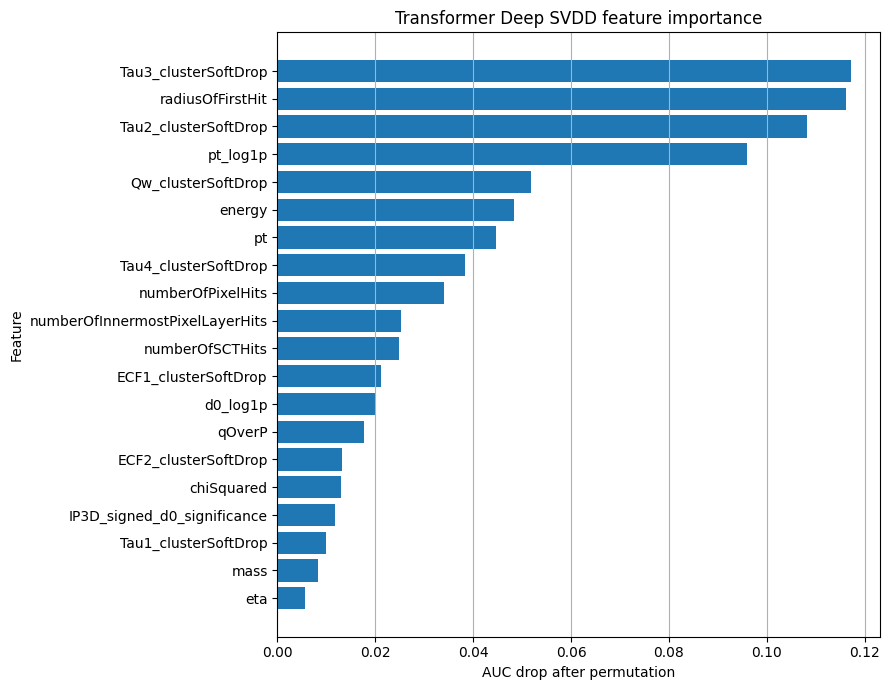

In [ ]:
# Misura quanto cala l'AUC quando rompiamo l'associazione tra una feature e l'evento.
# Per velocità usa un sottoinsieme di eventi.


DO_FEATURE_IMPORTANCE = True
MAX_EVENTS_PER_CLASS = 5000

def subset_for_importance(Xj_bg, Xt_bg, m_bg, Xj_sig, Xt_sig, m_sig, max_events=5000):
    rng = np.random.default_rng(SEED)

    n_bg = min(max_events, Xj_bg.shape[0])
    n_sig = min(max_events, Xj_sig.shape[0])

    idx_bg = rng.choice(Xj_bg.shape[0], size=n_bg, replace=False)
    idx_sig = rng.choice(Xj_sig.shape[0], size=n_sig, replace=False)

    return (
        Xj_bg[idx_bg].copy(),
        Xt_bg[idx_bg].copy(),
        m_bg[idx_bg].copy(),
        Xj_sig[idx_sig].copy(),
        Xt_sig[idx_sig].copy(),
        m_sig[idx_sig].copy(),
    )


def best_auc_from_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])
    return max(roc_auc_score(y, s), roc_auc_score(y, -s))


def permutation_importance_transformer(
    model,
    center,
    Xj_bg,
    Xt_bg,
    m_bg,
    Xj_sig,
    Xt_sig,
    m_sig,
    jet_feature_names,
    track_feature_names,
):
    rng = np.random.default_rng(SEED)

    base_bg, _ = compute_svdd_scores(model, Xj_bg, Xt_bg, m_bg, center, batch_size=1024)
    base_sig, _ = compute_svdd_scores(model, Xj_sig, Xt_sig, m_sig, center, batch_size=1024)
    base_auc = best_auc_from_scores(base_bg, base_sig)

    rows = []

    # Jet feature permutation.
    for j, name in enumerate(jet_feature_names):
        Xj_all = np.concatenate([Xj_bg, Xj_sig], axis=0).copy()
        Xt_all = np.concatenate([Xt_bg, Xt_sig], axis=0).copy()
        m_all = np.concatenate([m_bg, m_sig], axis=0).copy()

        Xj_all[:, j] = rng.permutation(Xj_all[:, j])

        n_bg = Xj_bg.shape[0]
        s_bg, _ = compute_svdd_scores(model, Xj_all[:n_bg], Xt_all[:n_bg], m_all[:n_bg], center, batch_size=1024)
        s_sig, _ = compute_svdd_scores(model, Xj_all[n_bg:], Xt_all[n_bg:], m_all[n_bg:], center, batch_size=1024)

        auc_perm = best_auc_from_scores(s_bg, s_sig)

        rows.append({
            "feature_type": "jet",
            "feature": name,
            "base_auc": base_auc,
            "permuted_auc": auc_perm,
            "importance": base_auc - auc_perm,
        })

    # Track feature permutation.
    for j, name in enumerate(track_feature_names):
        Xj_all = np.concatenate([Xj_bg, Xj_sig], axis=0).copy()
        Xt_all = np.concatenate([Xt_bg, Xt_sig], axis=0).copy()
        m_all = np.concatenate([m_bg, m_sig], axis=0).copy()

        valid_values = Xt_all[:, :, j][m_all].copy()
        valid_values = rng.permutation(valid_values)
        Xt_all[:, :, j][m_all] = valid_values

        # Mantieni padding invalido a zero.
        Xt_all[~m_all] = 0.0

        n_bg = Xj_bg.shape[0]
        s_bg, _ = compute_svdd_scores(model, Xj_all[:n_bg], Xt_all[:n_bg], m_all[:n_bg], center, batch_size=1024)
        s_sig, _ = compute_svdd_scores(model, Xj_all[n_bg:], Xt_all[n_bg:], m_all[n_bg:], center, batch_size=1024)

        auc_perm = best_auc_from_scores(s_bg, s_sig)

        rows.append({
            "feature_type": "track",
            "feature": name,
            "base_auc": base_auc,
            "permuted_auc": auc_perm,
            "importance": base_auc - auc_perm,
        })

    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)


if DO_FEATURE_IMPORTANCE:
    imp_inputs = subset_for_importance(
        X_jets_bkg_test,
        X_tracks_bkg_test,
        mask_bkg_test,
        X_jets_sig,
        X_tracks_sig,
        mask_sig,
        max_events=MAX_EVENTS_PER_CLASS,
    )

    df_importance = permutation_importance_transformer(
        model,
        center,
        *imp_inputs,
        jet_feature_names=jet_feature_names,
        track_feature_names=track_feature_names,
    )

    df_importance.to_csv(OUTPUT_DIR / "transformer_deep_svdd_feature_importance.csv", index=False)
    display(df_importance.head(20))

    top = df_importance.head(20).iloc[::-1]

    plt.figure(figsize=(9, 7))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("AUC drop after permutation")
    plt.ylabel("Feature")
    plt.title("Transformer Deep SVDD feature importance")
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "transformer_deep_svdd_feature_importance.png", dpi=200)
    plt.show()
else:
    df_importance = pd.DataFrame()
    print("Feature importance skipped.")

interessante notare come il trandormer, vedendo tutto nell'insieme,

## 20. Salvataggio finale

In [ ]:
results_summary = {
    "model": "Transformer Deep SVDD",
    "score": "SVDD distance",
    "auc": float(eval_main["auc"]),
    "auc_inverted": float(eval_main["auc_inverted"]),
    "best_auc": float(eval_main["best_auc"]),
    "flipped": bool(eval_main["flipped"]),
    "auc_latent_logreg": float(auc_latent_logreg),
    "n_track_features": int(n_track_features),
    "n_jet_features": int(n_jet_features),
    "max_tracks": int(max_tracks),
    "d_model": int(D_MODEL),
    "n_heads": int(N_HEADS),
    "n_layers": int(N_LAYERS),
    "dim_feedforward": int(DIM_FEEDFORWARD),
    "latent_dim": int(LATENT_DIM),
    "dropout": float(DROPOUT),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "hparam_tuning_used": bool("transformer_tuning_results_df" in globals()),
    "hparam_selection_score": float(BEST_TRANSFORMER_CONFIG.get("selection_score", np.nan)) if "BEST_TRANSFORMER_CONFIG" in globals() else float("nan"),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
}

for _, row in bg_checks.iterrows():
    key = row["comparison"].replace(" ", "_").replace("vs", "VS")
    results_summary[f"{key}_best_auc"] = float(row["best_auc"])

with open(OUTPUT_DIR / "transformer_deep_svdd_config.json", "w") as f:
    json.dump(
        {
            **results_summary,
            "processed_path": str(PROCESSED_PATH),
            "jet_feature_names": jet_feature_names,
            "track_feature_names": track_feature_names,
        },
        f,
        indent=2,
    )

eval_main["eff_table"].to_csv(OUTPUT_DIR / "transformer_deep_svdd_results.csv", index=False)
bg_checks.to_csv(OUTPUT_DIR / "transformer_deep_svdd_background_checks.csv", index=False)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "center": center.detach().cpu(),
        "config": results_summary,
        "jet_feature_names": jet_feature_names,
        "track_feature_names": track_feature_names,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "lr_history": lr_history,
    },
    OUTPUT_DIR / "transformer_deep_svdd_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "transformer_deep_svdd_scores.npz",
    scores_train=scores_train,
    scores_val=scores_val,
    scores_bkg_test=scores_bkg_test,
    scores_sig=scores_sig,
    Z_train=Z_train,
    Z_val=Z_val,
    Z_bkg_test=Z_bkg_test,
    Z_sig=Z_sig,
    center=center.detach().cpu().numpy(),
    bg_oriented=eval_main["bg_oriented"],
    sig_oriented=eval_main["sig_oriented"],
    fpr=eval_main["fpr"],
    tpr=eval_main["tpr"],
    thresholds=eval_main["thresholds"],
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
    auc=np.array(eval_main["auc"], dtype=np.float32),
    auc_inverted=np.array(eval_main["auc_inverted"], dtype=np.float32),
    best_auc=np.array(eval_main["best_auc"], dtype=np.float32),
    auc_latent_logreg=np.array(auc_latent_logreg, dtype=np.float32),
)

print("Saved:")
print(OUTPUT_DIR / "transformer_deep_svdd_model.pt")
print(OUTPUT_DIR / "transformer_deep_svdd_scores.npz")
print(OUTPUT_DIR / "transformer_deep_svdd_results.csv")
print(OUTPUT_DIR / "transformer_deep_svdd_background_checks.csv")
print(OUTPUT_DIR / "transformer_deep_svdd_config.json")
if DO_FEATURE_IMPORTANCE:
    print(OUTPUT_DIR / "transformer_deep_svdd_feature_importance.csv")
print("plots:", PLOTS_DIR)

Saved:
..\outputs\transformer_deep_svdd\transformer_deep_svdd_model.pt
..\outputs\transformer_deep_svdd\transformer_deep_svdd_scores.npz
..\outputs\transformer_deep_svdd\transformer_deep_svdd_results.csv
..\outputs\transformer_deep_svdd\transformer_deep_svdd_background_checks.csv
..\outputs\transformer_deep_svdd\transformer_deep_svdd_config.json
..\outputs\transformer_deep_svdd\transformer_deep_svdd_feature_importance.csv
plots: ..\outputs\transformer_deep_svdd\plots
